In [7]:
library(pROC)
library(caret)
library(dplyr)
library(glmnet)

In [8]:
load("/vol/projects/yzhang/500FG_aging/output/10_microbiome/microbiome_prediction.Rdata")

In [7]:
basicPhenos = read.csv("/vol/projects/yzhang/500FG_aging/output/02_Olink/Age_group_basicPhenos.csv")
head(basicPhenos)
#basicPhenos <- basicPhenos[!is.na(basicPhenos$Age), ] None missing value
dim(basicPhenos)

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
1,2,HV043,male,18,182,50,15.09480,Married,University student,European,Rarely,Yes,Yes,16,12,346,2013,Group 1
2,16,HV515,male,18,170,62,21.45329,Cohabitation,University student,European,Once a month,No,Yes,8,12,338,2014,Group 1
3,41,HV518,male,18,180,67,20.67901,Single living alone,University student,European,Rarely,No,No,1,12,331,2014,Group 1
4,51,HV314,male,18,181,74,22.58783,Married,Middelbaar beroepsonderwijs (MBO),European,Never,No,No,24,11,324,2014,Group 1
5,56,HV497,female,18,157,49,19.87910,Married,Hogeschool opleiding (HBO),Asian,Rarely,No,No,24,11,324,2014,Group 1
6,148,HV454,female,18,167,50,17.92822,Married,University student,European,Rarely,No,Yes,20,10,290,2014,Group 1


[1] 527  18

In [8]:
microbiome <- read.table("/vol/projects/CIIM/cohorts_old/500FG/Molecular_phenotype/500FG_microbiome_pathways.txt", header = TRUE, sep = "", stringsAsFactors = FALSE)
head(microbiome)
dim(microbiome)
any(is.na(microbiome))

,PWY.6834..spermidine.biosynthesis.III,FERMENTATION.PWY..mixed.acid.fermentation,PWY.5686..UMP.biosynthesis,PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II,VALDEG.PWY..L.valine.degradation.I,PPGPPMET.PWY..ppGpp.biosynthesis,CHLOROPHYLL.SYN..chlorophyllide.a.biosynthesis.I..aerobic..light.dependent.,GLYCOGENSYNTH.PWY..glycogen.biosynthesis.I..from.ADP.D.Glucose.,PWY.7094..fatty.acid.salvage,TCA.GLYOX.BYPASS..superpathway.of.glyoxylate.bypass.and.TCA,⋯,COBALSYN.PWY..adenosylcobalamin.salvage.from.cobinamide.I,PWY.822..fructan.biosynthesis,P461.PWY..hexitol.fermentation.to.lactate..formate..ethanol.and.acetate,METHGLYUT.PWY..superpathway.of.methylglyoxal.degradation,PWY.7377..cob.II.yrinate.a.c.diamide.biosynthesis.I..early.cobalt.insertion.,PWY.6518..glycocholate.metabolism..bacteria.,ECASYN.PWY..enterobacterial.common.antigen.biosynthesis,PWY.6785..hydrogen.production.VIII,PWY.5724..superpathway.of.atrazine.degradation,PWY.7196..superpathway.of.pyrimidine.ribonucleosides.salvage
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV531,105.9234,1709.793,4675.400,5350.948,142.5939,340.8828,101.03553,7878.11010,2547.691,122.1253,⋯,2615.627,106.7624,740.3582,145.2831,155.5064,204.7743,108.2518,0.0000,101.0818,2368.077
HV532,111.9052,2419.922,4742.467,5256.545,156.8008,1199.9141,116.37555,-650.90151,2676.461,107.1662,⋯,2459.579,111.9338,869.5886,508.5559,175.2812,298.9233,106.1919,0.0000,101.7388,2339.662
HV533,104.1252,3060.407,5050.507,5322.419,133.2463,2272.5025,99.44764,260.94155,2133.189,180.5580,⋯,1856.333,102.0389,585.4480,127.1976,129.4395,309.5235,106.8537,0.0000,100.7286,2613.771
HV534,103.8862,2039.811,5783.870,4835.498,176.4493,2701.3976,140.63273,6826.20960,1886.170,104.7976,⋯,1591.879,103.7443,802.2063,642.2370,123.8644,302.2354,0.0000,0.0000,102.4864,1728.282
HV305,110.1563,2617.544,4911.302,5326.415,133.8508,2103.9627,102.36591,714.51235,2290.786,149.5210,⋯,2175.147,103.0316,648.8517,151.3800,164.2915,480.1675,103.7260,100.9269,101.2753,1926.143
HV352,104.4967,3421.462,4586.430,5412.430,118.0942,2519.6043,101.28686,41.95943,2307.831,171.1047,⋯,2719.372,107.6621,1607.8486,130.8270,119.8968,109.4525,110.1730,100.8376,101.2423,2123.012


[1] 425 524

[1] FALSE

In [9]:
# prepare cytokine_filter and pheno_filter_match
idx = intersect(rownames(microbiome), basicPhenos$ID_500fg) 
length(idx) #458samples
microbiome_filter = microbiome[which(rownames(microbiome) %in% idx),]
head(microbiome_filter)  #458samples,1596 metabolite
dim(microbiome_filter)

basicPhenos_filter = basicPhenos %>% filter(ID_500fg %in% idx)
head(basicPhenos_filter) #458samples
dim(basicPhenos_filter)

sum(rownames(microbiome_filter) == basicPhenos_filter$ID_500fg)

basicPhenos_filter_match = basicPhenos_filter[match(rownames(microbiome_filter), basicPhenos_filter$ID_500fg), ]

sum(basicPhenos_filter_match$ID_500fg == rownames(microbiome))
head(basicPhenos_filter_match) 
dim(basicPhenos_filter_match) #458samples

[1] 409

,PWY.6834..spermidine.biosynthesis.III,FERMENTATION.PWY..mixed.acid.fermentation,PWY.5686..UMP.biosynthesis,PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II,VALDEG.PWY..L.valine.degradation.I,PPGPPMET.PWY..ppGpp.biosynthesis,CHLOROPHYLL.SYN..chlorophyllide.a.biosynthesis.I..aerobic..light.dependent.,GLYCOGENSYNTH.PWY..glycogen.biosynthesis.I..from.ADP.D.Glucose.,PWY.7094..fatty.acid.salvage,TCA.GLYOX.BYPASS..superpathway.of.glyoxylate.bypass.and.TCA,⋯,COBALSYN.PWY..adenosylcobalamin.salvage.from.cobinamide.I,PWY.822..fructan.biosynthesis,P461.PWY..hexitol.fermentation.to.lactate..formate..ethanol.and.acetate,METHGLYUT.PWY..superpathway.of.methylglyoxal.degradation,PWY.7377..cob.II.yrinate.a.c.diamide.biosynthesis.I..early.cobalt.insertion.,PWY.6518..glycocholate.metabolism..bacteria.,ECASYN.PWY..enterobacterial.common.antigen.biosynthesis,PWY.6785..hydrogen.production.VIII,PWY.5724..superpathway.of.atrazine.degradation,PWY.7196..superpathway.of.pyrimidine.ribonucleosides.salvage
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV531,105.9234,1709.793,4675.400,5350.948,142.5939,340.8828,101.03553,7878.11010,2547.691,122.1253,⋯,2615.627,106.7624,740.3582,145.2831,155.5064,204.7743,108.2518,0.0000,101.0818,2368.077
HV532,111.9052,2419.922,4742.467,5256.545,156.8008,1199.9141,116.37555,-650.90151,2676.461,107.1662,⋯,2459.579,111.9338,869.5886,508.5559,175.2812,298.9233,106.1919,0.0000,101.7388,2339.662
HV533,104.1252,3060.407,5050.507,5322.419,133.2463,2272.5025,99.44764,260.94155,2133.189,180.5580,⋯,1856.333,102.0389,585.4480,127.1976,129.4395,309.5235,106.8537,0.0000,100.7286,2613.771
HV534,103.8862,2039.811,5783.870,4835.498,176.4493,2701.3976,140.63273,6826.20960,1886.170,104.7976,⋯,1591.879,103.7443,802.2063,642.2370,123.8644,302.2354,0.0000,0.0000,102.4864,1728.282
HV305,110.1563,2617.544,4911.302,5326.415,133.8508,2103.9627,102.36591,714.51235,2290.786,149.5210,⋯,2175.147,103.0316,648.8517,151.3800,164.2915,480.1675,103.7260,100.9269,101.2753,1926.143
HV352,104.4967,3421.462,4586.430,5412.430,118.0942,2519.6043,101.28686,41.95943,2307.831,171.1047,⋯,2719.372,107.6621,1607.8486,130.8270,119.8968,109.4525,110.1730,100.8376,101.2423,2123.012


[1] 409 524

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
1,2,HV043,male,18,182,50,15.09480,Married,University student,European,Rarely,Yes,Yes,16,12,346,2013,Group 1
2,16,HV515,male,18,170,62,21.45329,Cohabitation,University student,European,Once a month,No,Yes,8,12,338,2014,Group 1
3,41,HV518,male,18,180,67,20.67901,Single living alone,University student,European,Rarely,No,No,1,12,331,2014,Group 1
4,51,HV314,male,18,181,74,22.58783,Married,Middelbaar beroepsonderwijs (MBO),European,Never,No,No,24,11,324,2014,Group 1
5,148,HV454,female,18,167,50,17.92822,Married,University student,European,Rarely,No,Yes,20,10,290,2014,Group 1
6,151,HV461,male,18,183,73,21.79820,Married,University student,European,Rarely,Yes,Yes,20,10,290,2014,Group 1


[1] 409  18

[1] 2

Warning message in basicPhenos_filter_match$ID_500fg == rownames(microbiome):
“longer object length is not a multiple of shorter object length”


[1] 16

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
189,23,HV531,female,23,165,57,20.93664,Cohabitation,University student,European,Rarely,No,Yes,8,12,338,2014,Group 3
190,24,HV532,male,23,190,84,23.26870,Single living alone,University student,European,Once a month,Yes,Yes,8,12,338,2014,Group 3
231,25,HV533,female,24,173,60,20.04745,Cohabitation,University student,European,Rarely,No,Yes,8,12,338,2014,Group 4
145,26,HV534,male,22,174,74,24.44180,Cohabitation,University student,European,Daily,No,No,8,12,338,2014,Group 3
224,533,HV305,female,23,174,69,22.79033,Single living alone,University student,European,Once a month,No,Yes,NA,NA,NA,NA,Group 3
278,296,HV352,male,25,180,84,25.92593,Cohabitation,University student,European,Daily,No,No,28,7,208,2014,Group 4


[1] 409  18

In [9]:
microbiome_age <- cbind(microbiome_filter, Age = basicPhenos_filter_match$Age)
head(microbiome_age)
dim(microbiome_age)

,PWY.6834..spermidine.biosynthesis.III,FERMENTATION.PWY..mixed.acid.fermentation,PWY.5686..UMP.biosynthesis,PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II,VALDEG.PWY..L.valine.degradation.I,PPGPPMET.PWY..ppGpp.biosynthesis,CHLOROPHYLL.SYN..chlorophyllide.a.biosynthesis.I..aerobic..light.dependent.,GLYCOGENSYNTH.PWY..glycogen.biosynthesis.I..from.ADP.D.Glucose.,PWY.7094..fatty.acid.salvage,TCA.GLYOX.BYPASS..superpathway.of.glyoxylate.bypass.and.TCA,⋯,PWY.822..fructan.biosynthesis,P461.PWY..hexitol.fermentation.to.lactate..formate..ethanol.and.acetate,METHGLYUT.PWY..superpathway.of.methylglyoxal.degradation,PWY.7377..cob.II.yrinate.a.c.diamide.biosynthesis.I..early.cobalt.insertion.,PWY.6518..glycocholate.metabolism..bacteria.,ECASYN.PWY..enterobacterial.common.antigen.biosynthesis,PWY.6785..hydrogen.production.VIII,PWY.5724..superpathway.of.atrazine.degradation,PWY.7196..superpathway.of.pyrimidine.ribonucleosides.salvage,Age
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
HV531,105.9234,1709.793,4675.400,5350.948,142.5939,340.8828,101.03553,7878.11010,2547.691,122.1253,⋯,106.7624,740.3582,145.2831,155.5064,204.7743,108.2518,0.0000,101.0818,2368.077,23
HV532,111.9052,2419.922,4742.467,5256.545,156.8008,1199.9141,116.37555,-650.90151,2676.461,107.1662,⋯,111.9338,869.5886,508.5559,175.2812,298.9233,106.1919,0.0000,101.7388,2339.662,23
HV533,104.1252,3060.407,5050.507,5322.419,133.2463,2272.5025,99.44764,260.94155,2133.189,180.5580,⋯,102.0389,585.4480,127.1976,129.4395,309.5235,106.8537,0.0000,100.7286,2613.771,24
HV534,103.8862,2039.811,5783.870,4835.498,176.4493,2701.3976,140.63273,6826.20960,1886.170,104.7976,⋯,103.7443,802.2063,642.2370,123.8644,302.2354,0.0000,0.0000,102.4864,1728.282,22
HV305,110.1563,2617.544,4911.302,5326.415,133.8508,2103.9627,102.36591,714.51235,2290.786,149.5210,⋯,103.0316,648.8517,151.3800,164.2915,480.1675,103.7260,100.9269,101.2753,1926.143,23
HV352,104.4967,3421.462,4586.430,5412.430,118.0942,2519.6043,101.28686,41.95943,2307.831,171.1047,⋯,107.6621,1607.8486,130.8270,119.8968,109.4525,110.1730,100.8376,101.2423,2123.012,25


[1] 409 525

In [10]:
##perform 100 times
##perform 100 times
# Custom function to train and evaluate the model
train_and_evaluate <- function(data, seed, iteration) {
  set.seed(seed)
  
  # Split data into training and validation sets
  splitSample <- createDataPartition(data$Age, p = 0.7, list = FALSE)
  training <- data[splitSample, ]
  validation <- data[-splitSample, ]
   
    # Set up the grid for hyperparameter tuning
  netGrid <- expand.grid(.alpha = seq(0.1, 0.9, by = 0.1), .lambda = seq(0, 1, by = 0.01))    
  netctrl <- trainControl(method = "repeatedcv", number = 10, repeats = 5) 
  
    # Train the model
  netFit <- train(Age ~ ., data = training, method = "glmnet", metric = "RMSE",
                  tuneGrid = netGrid, trControl = netctrl, preProcess = "scale")
  
  # Make predictions on training and validation sets
  train_predictions <- predict(netFit, newdata = training)
  val_predictions <- predict(netFit, newdata = validation)
  
    # Save predicted age for each sample   
   pred_df <- rbind(
    data.frame(
      iteration = iteration,
      set = "train",
      sample_id = rownames(training),
      Age_true = training$Age,
      Age_pred = as.numeric(train_predictions),
      stringsAsFactors = FALSE
    ),
    data.frame(
      iteration = iteration,
      set = "validation",
      sample_id = rownames(validation),
      Age_true = validation$Age,
      Age_pred = as.numeric(val_predictions),
      stringsAsFactors = FALSE
    )
  )
  # Compute performance metrics for training set
  train_rmse <- sqrt(mean((training$Age - train_predictions)^2))  # RMSE
  train_mse <- mean((training$Age - train_predictions)^2)         # MSE
  train_r_squared <- cor(training$Age, train_predictions)^2       # R²
  
  # Compute performance metrics for validation set
  val_rmse <- sqrt(mean((validation$Age - val_predictions)^2))    # RMSE
  val_mse <- mean((validation$Age - val_predictions)^2)           # MSE
  val_r_squared <- cor(validation$Age, val_predictions)^2         # R²
  
  # Return metrics
  list(
    train_RMSE = train_rmse,
    train_MSE = train_mse,
    train_R2 = train_r_squared,
    val_RMSE = val_rmse,
    val_MSE = val_mse,
    val_R2 = val_r_squared,
    best_model = netFit,
    # selected_features = selected_features,
    predictions = pred_df
  )
}


In [11]:
# Run the training process 100 times
set.seed(1)
results <- lapply(1:100, function(i) train_and_evaluate(microbiome_age, seed = i, iteration = i))

# Extract metrics for training and validation sets
train_rmse_values <- sapply(results, function(x) x$train_RMSE)
train_mse_values <- sapply(results, function(x) x$train_MSE)
train_r2_values <- sapply(results, function(x) x$train_R2)

val_rmse_values <- sapply(results, function(x) x$val_RMSE)
val_mse_values <- sapply(results, function(x) x$val_MSE)
val_r2_values <- sapply(results, function(x) x$val_R2)

# Calculate mean and standard deviation for each metric
metrics_summary <- data.frame(
  Metric = c("Train RMSE", "Validation RMSE", 
             "Train MSE", "Validation MSE", 
             "Train R²", "Validation R²"),
  Mean = c(mean(train_rmse_values), mean(val_rmse_values),
           mean(train_mse_values), mean(val_mse_values),
           mean(train_r2_values), mean(val_r2_values)),
  SD = c(sd(train_rmse_values), sd(val_rmse_values),
         sd(train_mse_values), sd(val_mse_values),
         sd(train_r2_values), sd(val_r2_values))
)

# Print summary
head(metrics_summary)

,Metric,Mean,SD
,<chr>,<dbl>,<dbl>
1,Train RMSE,12.76983300,0.59263164
2,Validation RMSE,17.55803136,6.31740108
3,Train MSE,163.41633493,14.95193049
4,Validation MSE,347.79492598,319.26128503
5,Train R²,0.18135699,0.05707737
6,Validation R²,0.02074359,0.01842682


In [12]:
saveRDS(results, "/vol/projects/yzhang/500FG_aging/output/12_prediction/elasticnet_orign_sample_feature/microbiome_prediction_elastic_results.rds")

all_predictions <- do.call(rbind, lapply(results, function(x) x$predictions))
write.csv(all_predictions, file = "/vol/projects/yzhang/500FG_aging/output/12_prediction/elasticnet_orign_sample_feature/microbiome_pre_age_elasticnet_orign_sample_feature.csv", row.names = FALSE)

null device 
          1

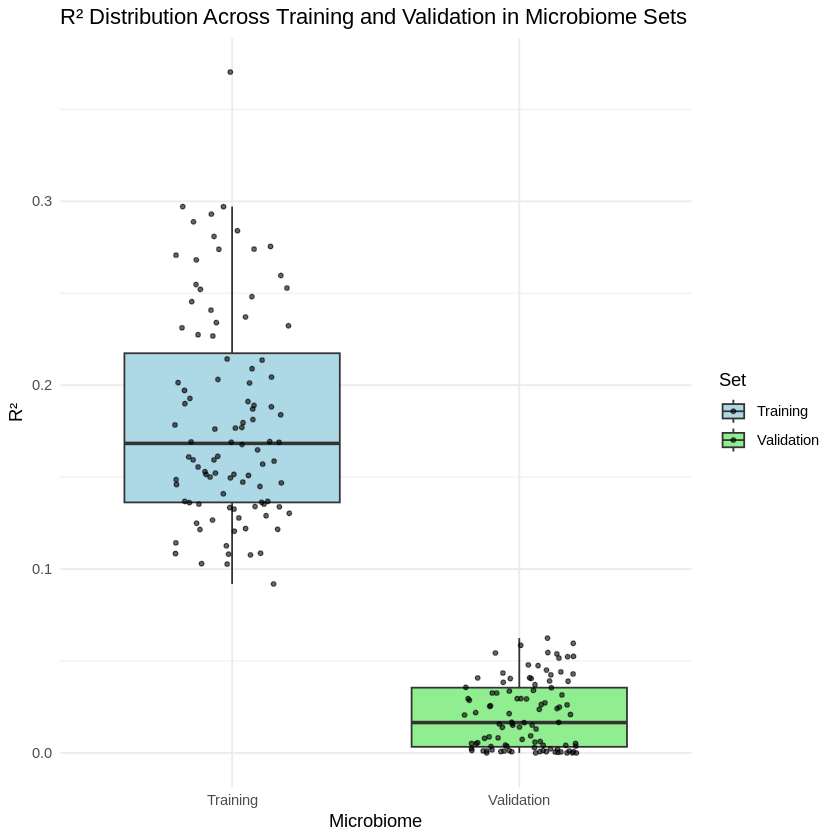

In [13]:
# Combine R² metrics into a single data frame for plotting
plot_data_r2 <- data.frame(
  Set = rep(c("Training", "Validation"), each = 100),
  R2 = c(train_r2_values, val_r2_values)
)

# Plot only R²
# ppi <- 300
# png("/vol/projects/yzhang/500FG_aging/output/10_microbiome/microbiome_cross_validation.png", 
#     width = 5 * ppi, height = 4 * ppi, res = ppi)

g<-ggplot(plot_data_r2, aes(x = Set, y = R2, fill = Set)) +
  geom_boxplot(outlier.shape = NA) +  # Boxplot without outliers
  geom_jitter(position = position_jitterdodge(), size = 1, alpha = 0.6, color = "black") +  # Scatter points
  labs(title = "R² Distribution Across Training and Validation in Microbiome Sets",
       x = "Microbiome",
       y = "R²") +
  theme_minimal() +
  scale_fill_manual(values = c("lightblue", "lightgreen")) +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5))

print(g)
dev.off()
print(g)

In [14]:
save.image("/vol/projects/yzhang/500FG_aging/output/10_microbiome/microbiome_elasticnet_orign_sample_prediction.Rdata")